[data] 17-section 그래프(사전 필터링 없음): 노드 1581개, 엣지 2992개
[target_mp] ['26,444,055', '29,211,881', '31,397,729', '33,087,380', '33,704,378', '32,835,017', '30,467,844', '27,734,809', '26,413,902', '27,985,091', '32,922,019', '39,716,721', '45,526,897', '47,458,156', '44,876,148', '39,505,207', '35,005,895']
[Stage 0] Static shape/index dry-run 시작...
[Stage 0] GPU 메모리 사용량: 9.2 MB
[Stage 0] 통과 — 노드 1581개, 엣지 2992개, z_gate shape (17, 5), 연속 파트 두께 불변 확인 완료.
[gradcheck] dMp/dt OK -- autograd=3.4990e+08, FD=3.4976e+08, rel_err=4.09e-04, dMp/dt>0 확인
[mass] target_area = 24056.9 mm^2 (17-section 합산 초기 단면적)
[collision v5] 153쌍(섹션x파트쌍) 부호 앵커 산정 완료

[ AI_design_v1 ] ASWC Training | 17 sections | Section-aware gating (17x2) | Stage1<50 Stage2<200 Stage3<250
Epoch    0 || loss=1.3226 | MpErr=8.41% | l_continuity=0.0000(w=1.000) | area=24059.9 | candidate_gate_mean=1.000
Epoch   10 || loss=2.7732 | MpErr=17.31% | l_continuity=0.0000(w=1.000) | area=17712.6 | candidate_gate_mean=1.000
[Gate Active] epoch 

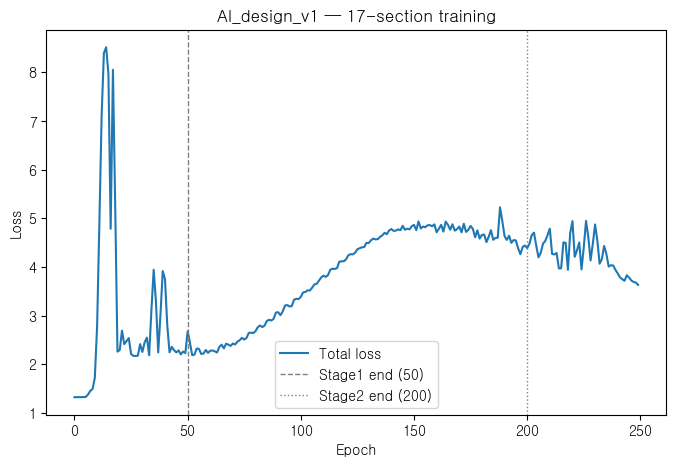

In [11]:
#!/usr/bin/env python
# coding: utf-8

"""
AI_design_v1.py
─────────────────────────────────────
docs/command/command_v1.md 실행 (2026-07-27 /synod debug 정정 반영). `uni-section/code/uni_section_v18.py`
(단일 섹션, section_id=0 고정)를 17섹션 B-pillar로 확장한다. uni_section_v18.py 자체는 수정하지 않고
import해서 재사용한다.

**[정정 이력]** 최초 버전은 part 삭제/재등장을 `configs/part_schedule_v1.json`(사람이 미리 짜는 존재
스케줄)과 9번째 노드 컬럼(`logical_part_id`)으로 구현했으나, 사용자가 "삭제/재등장은 학습 중 목표 Mp를
맞추다 보니 특정 섹션에서 자연히 켜지거나 꺼지는 것"이라고 정정함. 이번 버전은:
  - 노드 feature 8열 그대로 유지(신규 컬럼 없음), 17섹션 모두 처음부터 5-part 전부를 노드로 포함
    (사전 필터링 없음).
  - `log_alpha`를 파트당 1개(원본, shape (5,))에서 **(section, candidate_part)당 1개** (shape
    (17, len(CANDIDATE_PARTS))=(17,2))로 확장 — 원본의 HardConcrete 게이팅(`compute_gates`)을 그대로
    재사용하되 flatten(-1)→호출→unflatten으로 감싼다(브로드캐스트 버그 방지, /synod debug 세션에서
    Gemini/OpenAI 둘 다 독립적으로 제안한 안전한 패턴).
  - `pruning_state`를 (17, len(CANDIDATE_PARTS)) 텐서로 벡터화(ALIVE/PENDING_DELETE/DELETED
    히스테리시스, 원본 update_pruning_state의 for-loop 로직을 벡터 연산으로 이식).
  - 두께 pooling은 물리 part_id만으로 분기(연속 파트=전 섹션 공통, candidate 파트=섹션별 독립) —
    이미 섹션별 독립 pooling이므로 "재등장 시 새 두께"가 재넘버링 없이 자동 성립.
  - z_gate 히트맵(17×2) 시각화 추가 — 어느 섹션에서 patch가 학습을 통해 켜지고 꺼졌는지 확인.

/synod debug 세션(2026-07-27): Gemini(flash, conf 95)와 OpenAI(o3, conf 85) 모두 flatten/unflatten
wrapper와 (17,5) 전체 z_gate 조립 방식을 독립적으로 제안해 수렴. OpenAI가 지적한 실무 함정(Stage 0에서
"5파트 전부 동일 두께" 식으로 검사하면 실패 — 연속 파트만 검사해야 함, 로그 포맷 문자열에 텐서를 그대로
넣으면 콘솔 폭주 등)을 반영했다.
"""

import copy
import json
import os
import math

import numpy as np
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'Gulim'

from torch_geometric.data import Data

import sys
# __file__은 일반 스크립트 실행 시에는 존재하지만 Jupyter 노트북 셀에서 직접 실행할 때는 정의되지
# 않는다(NameError) — 이 경우 현재 작업 디렉터리(os.getcwd())를 기준으로 삼는다. 노트북은 보통
# 이 파일이 있는 CGNN 디렉터리에서 실행되므로 getcwd()가 안전한 대체값이다.
_THIS_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
sys.path.insert(0, os.path.join(_THIS_DIR, 'uni-section', 'code'))
import uni_section_v18 as usv18


# ══════════════════════════════════════════════════════════════════
# SECTION 0: 17-section 데이터 생성 (command_v1.md §2 — 사전 필터링 없음)
# ══════════════════════════════════════════════════════════════════

NUM_SECTIONS = 17
CONTINUOUS_PARTS = usv18.S_PROTECT        # [0, 1, 2] — Outer Hat, Inner Plate, Inner Hat
CANDIDATE_PARTS = usv18.CANDIDATE_PARTS   # [3, 4] — Patch 1, Patch 2


def scale_factor(k: int) -> float:
    """initial_section.md §1: s(k) = 1.6 - 0.6*(k-1)/16, k=1..17(1-indexed, k=17이 원본/최상단).
    이 파일 내부에서는 0-indexed section_id(0=최상단 원본 ~ 16=최하단)를 쓰므로 k=section_id+1."""
    k1 = k + 1
    return 1.6 - 0.6 * (k1 - 1) / 16.0


def build_bpillar_17section():
    """build_bpillar_section()(uni_section_v18.py line 805)을 17번 호출해 스케일링 후 병합.
    [정정] 모든 섹션에 5-part 전부를 처음부터 노드로 포함한다 — 존재/삭제는 사전 필터링이 아니라
    학습된 게이트(§1 CGDN17)로 결정되므로 여기서는 어떤 노드도 걸러내지 않는다.
    반환: Data(x[N,8], edge_index, edge_attr, join_pairs)."""
    all_x, all_edge_index, all_edge_attr = [], [], []
    node_offset = 0

    for k in range(NUM_SECTIONS):
        base_data, _ = usv18.build_bpillar_section()
        x_k = base_data.x.clone()
        s = scale_factor(k)
        x_k[:, 0] *= s
        x_k[:, 1] *= s
        x_k[:, 5] = float(k)  # section_id

        edge_index_k = base_data.edge_index + node_offset
        edge_attr_k = base_data.edge_attr.clone()

        all_x.append(x_k)
        all_edge_index.append(edge_index_k)
        all_edge_attr.append(edge_attr_k)
        node_offset += x_k.shape[0]

    x = torch.cat(all_x, dim=0)
    edge_index = torch.cat(all_edge_index, dim=1)
    edge_attr = torch.cat(all_edge_attr, dim=0)
    join_pairs = torch.zeros((0, 2), dtype=torch.long)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, join_pairs=join_pairs)


# ══════════════════════════════════════════════════════════════════
# SECTION 1: CGDN17 — 두께 pooling 분기 + Section-Aware 학습된 게이팅 (command_v1.md §3)
# ══════════════════════════════════════════════════════════════════

class CGDN17(usv18.CGDN):
    """forward()는 uni_section_v18.CGDN.forward()(line 327-391)의 완전한 복제본이며:
      §3.1 두께 pooling: composite_key를 물리 part_id만으로 분기(연속=전 섹션 공통, candidate=섹션별 독립).
      §3.2 존재 게이트: log_alpha_candidates(17,len(CANDIDATE_PARTS)) 기반 section-aware HardConcrete.
    나머지 로직(좌표 예측, join_pairs)은 원본과 100% 동일하다."""

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        # 원본 self.log_alpha(shape (5,))는 그대로 두되(원본 코드 하위호환), 실제 게이팅에는
        # 아래 candidate 전용 파라미터를 사용한다.
        del self.log_alpha
        self.log_alpha_candidates = torch.nn.Parameter(
            torch.full((NUM_SECTIONS, len(CANDIDATE_PARTS)), 2.0)  # 원본 init_log_alpha=2.0과 동일 초기값
        )

    def compute_gates_multi(self, training, temperature):
        """원본 compute_gates()(line 188)는 1D 텐서만 받으므로, (17,len(CANDIDATE_PARTS))를
        flatten(-1)해서 그대로 통과시킨 뒤 동일 shape으로 unflatten한다 — 이 순서를 지켜야
        (17,2,17) 같은 유령 브로드캐스트 차원이 생기지 않는다(/synod debug 세션 확인)."""
        flat_log_alpha = self.log_alpha_candidates.reshape(-1)                 # (17*len(CANDIDATE_PARTS),)
        z_gate_flat, z_open_flat = usv18.compute_gates(
            flat_log_alpha, training=training, temperature=temperature, s_protect=None
        )
        z_gate_cand = z_gate_flat.view_as(self.log_alpha_candidates)           # (17, len(CANDIDATE_PARTS))
        z_open_cand = z_open_flat.view_as(self.log_alpha_candidates)

        device = flat_log_alpha.device
        z_gate = torch.ones(NUM_SECTIONS, self.num_parts, device=device)       # 연속 파트=1.0 고정(마스크 방식)
        z_open = torch.ones(NUM_SECTIONS, self.num_parts, device=device)
        cand_idx = torch.tensor(CANDIDATE_PARTS, device=device)
        z_gate[:, cand_idx] = z_gate_cand
        z_open[:, cand_idx] = z_open_cand
        return z_gate, z_open   # 각각 (17, 5)

    def forward(self, x, edge_index, edge_attr, target_mp,
                fix_x_mask, fix_y_mask, join_pairs=None, thickness_gate=1.0,
                gate_active=True, temperature=0.5):
        h = self.node_encoder(x)

        for i, block in enumerate(self.blocks):
            gamma, beta = self.film_generators[i](target_mp)
            h = block(h, edge_index, edge_attr, gamma, beta)

        delta_coords = self.coord_decoder(h)
        delta_coords = torch.clamp(delta_coords, -self.max_displacement, self.max_displacement)
        delta_x = delta_coords[:, 0:1] * (~fix_x_mask).float()
        delta_y = delta_coords[:, 1:2] * (~fix_y_mask).float()
        delta_coords = torch.cat([delta_x, delta_y], dim=1)
        new_coords = x[:, :2] + delta_coords

        if join_pairs is not None and join_pairs.shape[0] > 0:
            u_idx = join_pairs[:, 0]
            v_idx = join_pairs[:, 1]
            mid = (new_coords[u_idx] + new_coords[v_idx]) * 0.5
            new_coords = new_coords.clone()
            new_coords[u_idx] = mid
            new_coords[v_idx] = mid

        delta_t_raw = self.thickness_decoder(h)
        delta_t_raw = self.leaky_tanh(delta_t_raw) * self.DELTA_SCALE

        part_ids_local    = x[:, 4].long()
        section_ids_local = x[:, 5].long()
        t_initial         = x[:, 6].unsqueeze(1)

        # ── §3.1 두께 pooling: 물리 part_id만으로 분기 (logical_part_id 없음, command_v1.md 정정) ──
        continuous_ids = torch.tensor(CONTINUOUS_PARTS, device=x.device)
        is_continuous  = torch.isin(part_ids_local, continuous_ids)

        max_parts = int(part_ids_local.max().item()) + 1
        composite_key = torch.where(
            is_continuous,
            part_ids_local,                                              # 전 섹션 공통 pooling
            10_000 + section_ids_local * max_parts + part_ids_local,      # candidate 파트: 섹션별 독립
        )
        _, inverse = torch.unique(composite_key, return_inverse=True)
        num_groups = int(inverse.max().item()) + 1

        delta_t_1d  = delta_t_raw.squeeze(-1)
        group_sum   = torch.zeros(num_groups, device=x.device).scatter_add_(0, inverse, delta_t_1d)
        group_count = torch.zeros(num_groups, device=x.device).scatter_add_(0, inverse, torch.ones_like(delta_t_1d))
        group_mean  = group_sum / group_count.clamp(min=1)
        delta_t_part = group_mean[inverse].unsqueeze(-1)

        delta_t_part = delta_t_part * thickness_gate

        t_min, t_max = self.T_MIN, self.T_MAX
        t_initial_frac = (t_initial - t_min) / (t_max - t_min)
        t_initial_frac = torch.clamp(t_initial_frac, 1e-4, 1.0 - 1e-4)
        t_initial_logit = torch.logit(t_initial_frac)
        t_raw = t_min + (t_max - t_min) * torch.sigmoid(t_initial_logit + delta_t_part)

        # ── §3.2 존재 게이트: section-aware — 원본 z_gate[part_ids_local] 대신 섹션까지 인덱싱 ──
        if gate_active:
            z_gate, z_open = self.compute_gates_multi(training=self.training, temperature=temperature)  # (17,5)
        else:
            z_gate = torch.ones(NUM_SECTIONS, self.num_parts, device=x.device)
            z_open = torch.ones(NUM_SECTIONS, self.num_parts, device=x.device)

        part_gate_node = z_gate[section_ids_local, part_ids_local].unsqueeze(-1)
        t_final = t_raw * part_gate_node

        return new_coords, delta_coords, t_final, delta_t_part, z_gate, z_open


# ══════════════════════════════════════════════════════════════════
# SECTION 2: pruning_state 벡터화 (command_v1.md §3.3)
# ══════════════════════════════════════════════════════════════════

STATE_ALIVE, STATE_PENDING, STATE_DELETED = 0, 1, 2


def make_pruning_state_multi():
    n_cand = len(CANDIDATE_PARTS)
    return {
        'ewma_z':            torch.ones(NUM_SECTIONS, n_cand),
        'state':             torch.zeros(NUM_SECTIONS, n_cand, dtype=torch.long),
        'pending_duration':  torch.zeros(NUM_SECTIONS, n_cand, dtype=torch.long),
        'ewma_alpha': 0.15, 'thresh_low': 0.08, 'thresh_high': 0.15, 'confirm_epochs': 20,
    }


@torch.no_grad()
def update_pruning_state_multi(pruning_state, z_gate_candidates):
    """원본 update_pruning_state()(line 238-264)의 for-loop 히스테리시스를 (17,len(CANDIDATE_PARTS))
    전체에 대한 벡터 연산으로 이식. z_gate_candidates: (17, len(CANDIDATE_PARTS))."""
    a = pruning_state['ewma_alpha']
    ewma_z = pruning_state['ewma_z']
    state = pruning_state['state']
    dur = pruning_state['pending_duration']

    ewma_z.mul_(1 - a).add_(z_gate_candidates.detach().cpu(), alpha=a)

    thresh_low, thresh_high, confirm_epochs = (
        pruning_state['thresh_low'], pruning_state['thresh_high'], pruning_state['confirm_epochs'])

    # ALIVE -> PENDING_DELETE
    to_pending = (state == STATE_ALIVE) & (ewma_z < thresh_low)
    state[to_pending] = STATE_PENDING
    dur[to_pending] = 0

    # PENDING_DELETE -> ALIVE (회복)
    mask_pending = state == STATE_PENDING
    back_to_alive = mask_pending & (ewma_z > thresh_high)
    state[back_to_alive] = STATE_ALIVE
    dur[back_to_alive] = 0

    # PENDING_DELETE 유지 -> duration 증가
    still_pending = mask_pending & ~back_to_alive
    dur[still_pending] += 1

    # confirm_epochs 초과 -> DELETED
    newly_deleted = still_pending & (dur >= confirm_epochs)
    state[newly_deleted] = STATE_DELETED

    return newly_deleted  # (17, len(CANDIDATE_PARTS)) bool — 이번 스텝에 새로 확정된 (section, part)


def plot_gate_heatmap(z_gate, epoch, save_dir="reports/figures"):
    """z_gate: (17, 5) 텐서. candidate 파트(3,4)만 시각화 — 연속 파트는 항상 1.0이라 무의미."""
    os.makedirs(save_dir, exist_ok=True)
    cand = z_gate[:, CANDIDATE_PARTS].detach().cpu().numpy().T  # (len(CANDIDATE_PARTS), 17)
    fig, ax = plt.subplots(figsize=(12, 2.2))
    im = ax.imshow(cand, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
    ax.set_yticks(range(len(CANDIDATE_PARTS)))
    ax.set_yticklabels([f'part-{p}' for p in CANDIDATE_PARTS])
    ax.set_xticks(range(NUM_SECTIONS))
    ax.set_xlabel('section_id (0=top/original ~ 16=bottom)')
    ax.set_title(f'z_gate heatmap @ epoch {epoch}')
    fig.colorbar(im, ax=ax, fraction=0.03)
    fig.tight_layout()
    fig.savefig(os.path.join(save_dir, f'gate_heatmap_e{epoch:04d}.png'), dpi=150)
    plt.close(fig)


# ══════════════════════════════════════════════════════════════════
# SECTION 3: 형상 연속성 loss (command_v1.md §4.1 — 물리 part_id 사용으로 정정)
# ══════════════════════════════════════════════════════════════════

def compute_shape_continuity_loss(new_coords, section_ids, part_ids, threshold=2.0):
    """인접 섹션(k, k+1) 간, 같은 물리 part_id를 가진 노드끼리 스케일 정규화 후 hinge loss.
    threshold(mm) 이내 변화는 무패널티. candidate 파트가 z_gate≈0인 섹션에서는 두께가 이미 0에
    가까우므로, 이 loss가 걸려도 실제 구조에는 영향이 없다(command_v1.md §4.1 정정 사항)."""
    device = new_coords.device
    total = torch.tensor(0.0, device=device)
    n_terms = 0

    unique_secs = torch.unique(section_ids).long().sort()[0]
    for i in range(len(unique_secs) - 1):
        k_a, k_b = int(unique_secs[i].item()), int(unique_secs[i + 1].item())
        s_a, s_b = scale_factor(k_a), scale_factor(k_b)

        mask_a = section_ids == k_a
        mask_b = section_ids == k_b

        for pid in torch.unique(part_ids):
            pid_int = int(pid.item())
            ca = new_coords[mask_a & (part_ids == pid_int)] / s_a
            cb = new_coords[mask_b & (part_ids == pid_int)] / s_b
            if ca.shape[0] == 0 or cb.shape[0] == 0:
                continue
            dist = torch.cdist(ca, cb, p=2)
            min_dist, _ = torch.min(dist, dim=1)
            violation = torch.clamp(min_dist - threshold, min=0.0)
            total = total + torch.mean(violation ** 2)
            n_terms += 1

    if n_terms > 0:
        total = total / n_terms
    return total


def continuity_weight_schedule(epoch, stage2_end, w_max=1.0, w_min=0.05, beta=0.1):
    """학습 초반 크게(형태 붕괴 방지) -> 후반 sigmoid decay(로컬 Mp 만족 우선)."""
    return w_min + (w_max - w_min) / (1.0 + math.exp(beta * (epoch - stage2_end)))


# ══════════════════════════════════════════════════════════════════
# SECTION 4: GP 기반 목표 Mp (command_v1.md §5, 변경 없음)
# ══════════════════════════════════════════════════════════════════

INITIAL_MP_TABLE = [
    21_637_199, 23_286_535, 24_996_460, 26_766_975, 28_598_079,
    30_489_775, 32_442_063, 34_454_943, 36_528_416, 38_662_482,
    40_857_143, 43_112_398, 45_428_249, 47_804_695, 50_241_738,
    52_739_377, 55_297_613,
]


def generate_gp_target_mp(seed=None, sigma=0.25, ell=3.0):
    """initial_section.md §2 표 기준, 공간 상관 있는 GP 스무딩 +/-50% 목표 Mp 생성.
    반환: {section_id(int): target_mp(float)}."""
    rng = np.random.default_rng(seed) if seed is not None else np.random.default_rng()

    initial_mp = np.array(INITIAL_MP_TABLE, dtype=np.float64)
    sections = np.arange(NUM_SECTIONS, dtype=np.float64)
    K = sigma ** 2 * np.exp(-(sections[:, None] - sections[None, :]) ** 2 / (2 * ell ** 2))
    K += 1e-6 * np.eye(NUM_SECTIONS)
    alpha = rng.multivariate_normal(np.zeros(NUM_SECTIONS), K)
    alpha = np.clip(alpha, -0.5, 0.5)

    target_mp = initial_mp * (1.0 + alpha)
    return {k: float(target_mp[k]) for k in range(NUM_SECTIONS)}


# ══════════════════════════════════════════════════════════════════
# SECTION 5: Stage 0 — Static Shape/Index Dry-Run (command_v1.md §6.1, 정정 반영)
# ══════════════════════════════════════════════════════════════════

@torch.no_grad()
def run_static_dry_run(data, model, target_mps, device):
    """학습 없는(zero-grad) 정적 검증. [정정] x.shape[1]==8(9열 아님), z_gate/z_open shape (17,5),
    연속 파트(0,1,2)만 두께 불변 검사(candidate 파트는 섹션별로 달라야 정상이므로 검사 대상 아님)."""
    print("[Stage 0] Static shape/index dry-run 시작...")
    x = data.x

    assert x.shape[1] == 8, f"노드 feature가 8열이어야 함(정정: logical_part_id 없음) (실제: {x.shape[1]})"
    section_ids = x[:, 5].long()
    assert section_ids.min().item() == 0 and section_ids.max().item() == NUM_SECTIONS - 1, \
        f"section_id 범위가 [0,{NUM_SECTIONS-1}]이어야 함"
    part_ids = x[:, 4].long()
    for k in range(NUM_SECTIONS):
        parts_in_section = set(int(p.item()) for p in torch.unique(part_ids[section_ids == k]))
        assert parts_in_section == {0, 1, 2, 3, 4}, \
            f"섹션 {k}에 5-part 전부가 없음(사전 필터링 금지 위반): {parts_in_section}"
    assert data.edge_index.max().item() < x.shape[0], "edge_index가 노드 수를 벗어남"

    target_mp_node = torch.zeros((x.shape[0], 1), dtype=torch.float32, device=device)
    for section in torch.unique(section_ids):
        target_mp_node[section_ids == section] = target_mps[int(section.item())]

    fix_x_mask = x[:, 2].bool().unsqueeze(1)
    fix_y_mask = x[:, 3].bool().unsqueeze(1)

    new_coords, _, t_final, _, z_gate, z_open = model(
        x, data.edge_index, data.edge_attr, target_mp_node,
        fix_x_mask, fix_y_mask, data.join_pairs,
        thickness_gate=0.0, gate_active=True, temperature=1.0,
    )
    assert not torch.isnan(new_coords).any(), "forward() 결과 new_coords에 NaN"
    assert not torch.isnan(t_final).any(), "forward() 결과 t_final에 NaN"

    assert z_gate.shape == (NUM_SECTIONS, model.num_parts), f"z_gate shape 오류: {z_gate.shape}"
    assert torch.allclose(z_gate[:, CONTINUOUS_PARTS], torch.ones_like(z_gate[:, CONTINUOUS_PARTS])), \
        "연속 파트(S_PROTECT)의 z_gate가 1.0으로 고정되지 않음"

    # 연속 파트(0,1,2)만 두께가 전 섹션 동일한지 확인 — candidate 파트는 검사 대상 아님(정정)
    for pid in CONTINUOUS_PARTS:
        mask = (part_ids == pid)
        t_vals = t_final[mask].detach()
        spread = (t_vals.max() - t_vals.min()).item()
        assert spread < 1e-4, (
            f"연속 파트 part_id={pid}의 두께가 섹션 간 다름(spread={spread:.6f}) — composite_key 분기 오류"
        )

    if torch.cuda.is_available():
        mem_mb = torch.cuda.memory_allocated(device) / (1024 ** 2)
        print(f"[Stage 0] GPU 메모리 사용량: {mem_mb:.1f} MB")

    print(f"[Stage 0] 통과 — 노드 {x.shape[0]}개, 엣지 {data.edge_index.shape[1]}개, "
          f"z_gate shape {tuple(z_gate.shape)}, 연속 파트 두께 불변 확인 완료.")
    return True


# ══════════════════════════════════════════════════════════════════
# SECTION 6: train_step_multi / run_training_multi (command_v1.md §4)
# ══════════════════════════════════════════════════════════════════

ASWC_STAGE1_END = 50    # Global Coarse Fit: 좌표 freeze, thickness만 학습
ASWC_STAGE2_END = 200   # Sequential Refinement: 좌표+두께 동시 학습, 종료 시 연속 파트 두께 detach
ASWC_STAGE3_END = 250   # Global Relaxation: 좌표만 재학습, 두께는 계속 detach
GATE_VIZ_STRIDE = 20    # z_gate 히트맵 저장 주기


def train_step_multi(model, data, optimizer, target_mps, target_area,
                      epoch, max_epochs, weights, curriculum,
                      curriculum_ratio, collision_spec, alda_state,
                      pruning_state=None):
    model.train()
    optimizer.zero_grad()

    x          = data.x
    edge_index = data.edge_index
    edge_attr  = data.edge_attr
    join_pairs = data.join_pairs
    base_coords = x[:, :2].detach()

    fix_x_mask  = x[:, 2].bool().unsqueeze(1)
    fix_y_mask  = x[:, 3].bool().unsqueeze(1)
    part_ids    = x[:, 4]
    section_ids = x[:, 5]
    fy          = x[:, 7].unsqueeze(1)

    unique_sections = torch.unique(section_ids)

    target_mp_node = torch.zeros((x.shape[0], 1), dtype=torch.float32, device=x.device)
    for section in unique_sections:
        section_mask = (section_ids == section)
        target_mp_node[section_mask] = target_mps[int(section.item())]

    gate = usv18.thickness_gate_value(epoch)
    gate_active = epoch >= usv18.GATE_ACTIVE_EPOCH
    current_temp = usv18.compute_gate_temperature(epoch)

    new_coords, delta_coords, t_final, delta_t_part, z_gate, z_open = model(
        x, edge_index, edge_attr, target_mp_node,
        fix_x_mask, fix_y_mask, join_pairs, thickness_gate=gate,
        gate_active=gate_active, temperature=current_temp
    )

    if epoch < ASWC_STAGE1_END:
        new_coords = base_coords.detach() + 0.0 * (new_coords - base_coords.detach())

    if epoch >= ASWC_STAGE2_END:
        continuous_mask = torch.isin(part_ids.long(),
                                      torch.tensor(CONTINUOUS_PARTS, device=x.device))
        t_final = torch.where(continuous_mask.unsqueeze(1), t_final.detach(), t_final)

    l_phys_terms, pred_mp_tensors, pred_mp_sections = [], [], []
    for section in unique_sections:
        section_mask = (section_ids == section)
        coords_section = new_coords[section_mask]
        t_section = t_final[section_mask]
        fy_section = fy[section_mask]

        src, dst = edge_index
        edge_mask = section_mask[src] & section_mask[dst]
        edge_type = edge_attr[:, 3]
        physical_mask = edge_mask & torch.isclose(edge_type, torch.zeros_like(edge_type))
        edge_index_section = edge_index[:, physical_mask]

        local_index = torch.full((x.shape[0],), -1, dtype=torch.long, device=x.device)
        local_index[section_mask] = torch.arange(section_mask.sum(), device=x.device)
        edge_index_section = local_index[edge_index_section]

        pred_mp_section = usv18.calculate_mpl(coords_section, t_section, fy_section, edge_index_section)

        section_int = int(section.item())
        target_mp_section = torch.tensor(target_mps[section_int], dtype=torch.float32, device=x.device)

        l_phys_terms.append(usv18.asymmetric_huber_phys(pred_mp_section, target_mp_section))
        pred_mp_tensors.append(pred_mp_section)
        pred_mp_sections.append(pred_mp_section.item())

    l_phys_total = torch.stack(l_phys_terms).mean()
    pred_mp_total = torch.stack(pred_mp_tensors).sum()
    target_mp_total = torch.tensor(sum(target_mps.values()), dtype=torch.float32, device=x.device)

    pred_mp_sections = np.array(pred_mp_sections)
    mp_rel_err = float(np.abs(np.sum(pred_mp_sections) - sum(target_mps.values())) / sum(target_mps.values()))

    if pruning_state is not None:
        cand_idx = torch.tensor(CANDIDATE_PARTS, device=x.device)
        z_open_cand = z_open[:, cand_idx]                 # (17, len(CANDIDATE_PARTS))
        update_pruning_state_multi(pruning_state, z_open_cand)
        # 적응형 TAU_GATE는 원본과 동일하게 mp_rel_err 기반(섹션 게이트와 무관, 전역 스칼라 유지)
        current_tau_gate = usv18.TAU_GATE
    else:
        current_tau_gate = usv18.TAU_GATE

    gate_multiplier = float(torch.sigmoid(torch.tensor(usv18.SPARSE_K * (current_tau_gate - mp_rel_err))).item())
    w_sparse_effective = weights['w_sparse'] * gate_multiplier
    l_sparse = z_open[:, CANDIDATE_PARTS].mean()   # (17, len(CANDIDATE_PARTS)) 전체 평균
    contrib_sparse = w_sparse_effective * l_sparse

    contrib_entropy = torch.tensor(0.0, device=x.device)
    if gate_active:
        z_cand = z_open[:, CANDIDATE_PARTS]
        entropy = -torch.mean(z_cand * torch.log(z_cand + usv18.ENTROPY_EPS)
                               + (1.0 - z_cand) * torch.log(1.0 - z_cand + usv18.ENTROPY_EPS))
        contrib_entropy = (usv18.ALPHA_ENT * gate_multiplier) * entropy

    s_phys, s_smooth = 1.0, 1.0
    if curriculum:
        s_phys, s_smooth = usv18.get_curriculum_weights_v10(epoch, max_epochs, curriculum_ratio)

    l_smooth    = usv18.compute_smoothness_loss_angle(new_coords, edge_index, edge_attr)
    area, l_mass = usv18.compute_mass_loss(new_coords, t_final, edge_index, edge_attr, target_area)
    # z_gate는 collision loss에서 part별 스칼라를 기대(원본 line 632 z_gate[part]) — 섹션마다 다를 수
    # 있으므로 섹션 평균을 사용(연속 파트는 항상 1이라 영향 없음, candidate 파트만 근사가 생김을 인지).
    z_gate_part_avg = z_gate.mean(dim=0)  # (5,)
    l_collision = usv18.compute_collision_loss_v5(new_coords, t_final, part_ids, section_ids,
                                                   collision_spec, z_gate=z_gate_part_avg)
    l_order     = usv18.compute_mesh_order_loss(base_coords, new_coords, edge_index, edge_attr)
    l_anchor    = usv18.compute_anchor_loss(new_coords, base_coords, fix_x_mask, fix_y_mask)
    l_sat       = usv18.compute_saturation_loss(delta_t_part, delta_scale=model.DELTA_SCALE)

    w_continuity = continuity_weight_schedule(epoch, ASWC_STAGE2_END)
    l_continuity = compute_shape_continuity_loss(new_coords, section_ids, part_ids, threshold=2.0)
    contrib_continuity = w_continuity * l_continuity

    L_alda, g_Mp_val, g_col_val = usv18.compute_alda_loss(
        area, target_area, pred_mp_total, target_mp_total, l_collision, alda_state)
    L_alda_effective = L_alda * max(gate, 0.05)

    contrib_phys   = weights['w_phys']   * l_phys_total * s_phys
    contrib_smooth = weights['w_smooth'] * l_smooth     * s_smooth
    contrib_order  = weights['w_order']  * l_order
    contrib_anchor = weights['w_anchor'] * l_anchor
    contrib_sat    = weights['w_sat']    * l_sat

    loss = (contrib_phys + contrib_smooth + L_alda_effective
            + contrib_order + contrib_anchor + contrib_sat
            + contrib_sparse + contrib_entropy + contrib_continuity)

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 10.0)
    optimizer.step()

    return {
        "loss": loss.item(), "mp_rel_err": mp_rel_err,
        "l_continuity": l_continuity.item(), "w_continuity": w_continuity,
        "area": area.item(), "z_gate": z_gate.detach(),
        "gate_multiplier": gate_multiplier, "thickness_gate": gate,
    }


def run_training_multi(data, target_mps, target_area=None, max_epochs=ASWC_STAGE3_END,
                        lr=1e-3, weights=None, curriculum=True, curriculum_ratio=(0.2, 0.7)):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    data = data.to(device)

    model = CGDN17(
        in_channels=8, hidden_channels=128, num_layers=4, heads=4, edge_dim=4,
        max_displacement=50.0, num_parts=5, init_log_alpha=2.0,
    ).to(device)

    run_static_dry_run(data, model, target_mps, device)

    thick_param_ids = {id(p) for p in model.thickness_decoder.parameters()}
    gate_param_ids  = {id(model.log_alpha_candidates)}
    main_params  = [p for p in model.parameters() if id(p) not in thick_param_ids and id(p) not in gate_param_ids]
    thick_params = list(model.thickness_decoder.parameters())
    gate_params  = [model.log_alpha_candidates]
    optimizer = optim.AdamW(
        [{'params': main_params, 'name': 'main'},
         {'params': thick_params, 'name': 'thickness_decoder'},
         {'params': gate_params, 'name': 'gate_params', 'lr': 0.0}],
        lr=lr, weight_decay=1e-4)

    if weights is None:
        weights = {'w_phys': 10.0, 'w_order': 1.0, 'w_smooth': 0.5, 'w_anchor': 0.02, 'w_sat': 0.01,
                   'w_sparse': usv18.W_SPARSE}

    alda_state = usv18.make_alda_state()
    pruning_state = make_pruning_state_multi()

    x = data.x
    part_ids = x[:, 4]
    section_ids = x[:, 5]

    usv18.verify_thickness_gradient(x[:, :2], x[:, 6:7], x[:, 7:8], data.edge_index)

    if target_area is None:
        target_area, _ = usv18.compute_section_area(x[:, :2].cpu(), x[:, 6:7].cpu(), data.edge_index.cpu())
    print(f"[mass] target_area = {target_area:.1f} mm^2 (17-section 합산 초기 단면적)")

    collision_spec = usv18.build_collision_spec(x[:, :2], x[:, 6:7], part_ids, section_ids)
    print(f"[collision v5] {len(collision_spec)}쌍(섹션x파트쌍) 부호 앵커 산정 완료")

    history = {'loss': [], 'mp_rel_err': [], 'l_continuity': [], 'area': []}

    print(f"\n{'='*78}\n[ AI_design_v1 ] ASWC Training | 17 sections | Section-aware gating "
          f"({NUM_SECTIONS}x{len(CANDIDATE_PARTS)}) | Stage1<{ASWC_STAGE1_END} "
          f"Stage2<{ASWC_STAGE2_END} Stage3<{ASWC_STAGE3_END}\n{'='*78}")

    gate_stage_done = False
    for epoch in range(max_epochs):
        # ── [원본 uni_section_v18.run_training() line 1303-1310과 동일] ──
        # gate_params(log_alpha_candidates)는 optimizer 생성 시 lr=0.0으로 묶여 있다가
        # GATE_ACTIVE_EPOCH 시점에 별도로 lr=1e-2로 풀린다. 이 활성화를 빠뜨리면 34개 게이트가
        # 전혀 학습되지 않고 초기값(sigmoid(2.0)≈0.88 부근)에 고정된다 — 스모크 테스트에서
        # candidate_gate_mean이 205 epoch 내내 요지부동인 것으로 실제 확인된 버그.
        if (not gate_stage_done) and epoch == usv18.GATE_ACTIVE_EPOCH:
            for group in optimizer.param_groups:
                if group.get('name') == 'gate_params':
                    group['lr'] = 1e-2
            gate_stage_done = True
            print(f"[Gate Active] epoch {epoch}: gate_params lr -> 1e-2 "
                  f"(section-aware 게이트 학습 시작)")

        info = train_step_multi(model, data, optimizer, target_mps, target_area,
                                 epoch, max_epochs, weights, curriculum, curriculum_ratio,
                                 collision_spec, alda_state, pruning_state)
        history['loss'].append(info['loss'])
        history['mp_rel_err'].append(info['mp_rel_err'])
        history['l_continuity'].append(info['l_continuity'])
        history['area'].append(info['area'])

        if epoch % 10 == 0 or epoch == max_epochs - 1:
            # 텐서를 포맷 문자열에 직접 넣지 않고 스칼라로 축약(/synod debug 세션 지적 반영)
            gate_mean = info['z_gate'][:, CANDIDATE_PARTS].mean().item()
            print(f"Epoch {epoch:4d} || loss={info['loss']:.4f} | MpErr={info['mp_rel_err']*100:.2f}% "
                  f"| l_continuity={info['l_continuity']:.4f}(w={info['w_continuity']:.3f}) "
                  f"| area={info['area']:.1f} | candidate_gate_mean={gate_mean:.3f}")

        if epoch % GATE_VIZ_STRIDE == 0 or epoch == max_epochs - 1:
            plot_gate_heatmap(info['z_gate'], epoch)

    return model, history


# ══════════════════════════════════════════════════════════════════
# SECTION 7: __main__
# ══════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    import argparse
    parser = argparse.ArgumentParser()
    parser.add_argument("--epochs", type=int, default=ASWC_STAGE3_END)
    parser.add_argument("--seed", type=int, default=42)
    parser.add_argument("--dry-run-only", action="store_true",
                         help="Stage 0 static dry-run만 수행하고 종료 (학습 없음)")
    # Jupyter(ipykernel_launcher)로 실행하면 sys.argv에 "--f=...kernel-....json" 같은 커널 인자가
    # 섞여 들어와 parse_args()가 SystemExit(2)로 죽는다 — parse_known_args()로 낯선 인자는 무시한다.
    args, _unknown = parser.parse_known_args()

    os.makedirs("weights", exist_ok=True)
    os.makedirs("reports/figures", exist_ok=True)

    data = build_bpillar_17section()
    target_mps = generate_gp_target_mp(seed=args.seed)

    print(f"[data] 17-section 그래프(사전 필터링 없음): 노드 {data.x.shape[0]}개, 엣지 {data.edge_index.shape[1]}개")
    print(f"[target_mp] {[f'{v:,.0f}' for v in target_mps.values()]}")

    if args.dry_run_only:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model = CGDN17(in_channels=8, hidden_channels=128, num_layers=4, heads=4, edge_dim=4,
                        max_displacement=50.0, num_parts=5, init_log_alpha=2.0).to(device)
        run_static_dry_run(data.to(device), model, target_mps, device)
    else:
        model, history = run_training_multi(data, target_mps, max_epochs=args.epochs)

        torch.save(model.state_dict(), "weights/bpillar_17sec_best.pt")

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(history['loss'], label='Total loss')
        ax.axvline(ASWC_STAGE1_END, color='gray', linestyle='--', linewidth=1.0, label=f'Stage1 end ({ASWC_STAGE1_END})')
        ax.axvline(ASWC_STAGE2_END, color='gray', linestyle=':', linewidth=1.0, label=f'Stage2 end ({ASWC_STAGE2_END})')
        ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend(); ax.set_title('AI_design_v1 — 17-section training')
        fig.savefig("reports/figures/loss_curve.png", dpi=150)
        print("[done] weights/bpillar_17sec_best.pt, reports/figures/loss_curve.png, "
              "reports/figures/gate_heatmap_e*.png 저장 완료")


In [12]:
"""
AI_design_v1.py
─────────────────────────────────────
docs/command/command_v1.md 실행 (2026-07-27 /synod debug 정정 반영). `uni-section/code/uni_section_v18.py`
(단일 섹션, section_id=0 고정)를 17섹션 B-pillar로 확장한다. uni_section_v18.py 자체는 수정하지 않고
import해서 재사용한다.

**[정정 이력]** 최초 버전은 part 삭제/재등장을 `configs/part_schedule_v1.json`(사람이 미리 짜는 존재
스케줄)과 9번째 노드 컬럼(`logical_part_id`)으로 구현했으나, 사용자가 "삭제/재등장은 학습 중 목표 Mp를
맞추다 보니 특정 섹션에서 자연히 켜지거나 꺼지는 것"이라고 정정함. 이번 버전은:
  - 노드 feature 8열 그대로 유지(신규 컬럼 없음), 17섹션 모두 처음부터 5-part 전부를 노드로 포함
    (사전 필터링 없음).
  - `log_alpha`를 파트당 1개(원본, shape (5,))에서 **(section, candidate_part)당 1개** (shape
    (17, len(CANDIDATE_PARTS))=(17,2))로 확장 — 원본의 HardConcrete 게이팅(`compute_gates`)을 그대로
    재사용하되 flatten(-1)→호출→unflatten으로 감싼다(브로드캐스트 버그 방지, /synod debug 세션에서
    Gemini/OpenAI 둘 다 독립적으로 제안한 안전한 패턴).
  - `pruning_state`를 (17, len(CANDIDATE_PARTS)) 텐서로 벡터화(ALIVE/PENDING_DELETE/DELETED
    히스테리시스, 원본 update_pruning_state의 for-loop 로직을 벡터 연산으로 이식).
  - 두께 pooling은 물리 part_id만으로 분기(연속 파트=전 섹션 공통, candidate 파트=섹션별 독립) —
    이미 섹션별 독립 pooling이므로 "재등장 시 새 두께"가 재넘버링 없이 자동 성립.
  - z_gate 히트맵(17×2) 시각화 추가 — 어느 섹션에서 patch가 학습을 통해 켜지고 꺼졌는지 확인.

/synod debug 세션(2026-07-27): Gemini(flash, conf 95)와 OpenAI(o3, conf 85) 모두 flatten/unflatten
wrapper와 (17,5) 전체 z_gate 조립 방식을 독립적으로 제안해 수렴. OpenAI가 지적한 실무 함정(Stage 0에서
"5파트 전부 동일 두께" 식으로 검사하면 실패 — 연속 파트만 검사해야 함, 로그 포맷 문자열에 텐서를 그대로
넣으면 콘솔 폭주 등)을 반영했다.
"""

import copy
import json
import os
import math

import numpy as np
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'Gulim'

from torch_geometric.data import Data

import sys
# __file__은 일반 스크립트 실행 시에는 존재하지만 Jupyter 노트북 셀에서 직접 실행할 때는 정의되지
# 않는다(NameError) — 이 경우 현재 작업 디렉터리(os.getcwd())를 기준으로 삼는다. 노트북은 보통
# 이 파일이 있는 CGNN 디렉터리에서 실행되므로 getcwd()가 안전한 대체값이다.
_THIS_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
sys.path.insert(0, os.path.join(_THIS_DIR, 'uni-section', 'code'))
import uni_section_v18 as usv18


# ══════════════════════════════════════════════════════════════════
# SECTION 0: 17-section 데이터 생성 (command_v1.md §2 — 사전 필터링 없음)
# ══════════════════════════════════════════════════════════════════

NUM_SECTIONS = 17
CONTINUOUS_PARTS = usv18.S_PROTECT        # [0, 1, 2] — Outer Hat, Inner Plate, Inner Hat
CANDIDATE_PARTS = usv18.CANDIDATE_PARTS   # [3, 4] — Patch 1, Patch 2


def scale_factor(k: int) -> float:
    """initial_section.md §1: s(k) = 1.6 - 0.6*(k-1)/16, k=1..17(1-indexed, k=17이 원본/최상단).
    이 파일 내부에서는 0-indexed section_id(0=최상단 원본 ~ 16=최하단)를 쓰므로 k=section_id+1."""
    k1 = k + 1
    return 1.6 - 0.6 * (k1 - 1) / 16.0


def build_bpillar_17section():
    """build_bpillar_section()(uni_section_v18.py line 805)을 17번 호출해 스케일링 후 병합.
    [정정] 모든 섹션에 5-part 전부를 처음부터 노드로 포함한다 — 존재/삭제는 사전 필터링이 아니라
    학습된 게이트(§1 CGDN17)로 결정되므로 여기서는 어떤 노드도 걸러내지 않는다.
    반환: Data(x[N,8], edge_index, edge_attr, join_pairs)."""
    all_x, all_edge_index, all_edge_attr = [], [], []
    node_offset = 0

    for k in range(NUM_SECTIONS):
        base_data, _ = usv18.build_bpillar_section()
        x_k = base_data.x.clone()
        s = scale_factor(k)
        x_k[:, 0] *= s
        x_k[:, 1] *= s
        x_k[:, 5] = float(k)  # section_id

        edge_index_k = base_data.edge_index + node_offset
        edge_attr_k = base_data.edge_attr.clone()

        all_x.append(x_k)
        all_edge_index.append(edge_index_k)
        all_edge_attr.append(edge_attr_k)
        node_offset += x_k.shape[0]

    x = torch.cat(all_x, dim=0)
    edge_index = torch.cat(all_edge_index, dim=1)
    edge_attr = torch.cat(all_edge_attr, dim=0)
    join_pairs = torch.zeros((0, 2), dtype=torch.long)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, join_pairs=join_pairs)


# ══════════════════════════════════════════════════════════════════
# SECTION 1: CGDN17 — 두께 pooling 분기 + Section-Aware 학습된 게이팅 (command_v1.md §3)
# ══════════════════════════════════════════════════════════════════

class CGDN17(usv18.CGDN):
    """forward()는 uni_section_v18.CGDN.forward()(line 327-391)의 완전한 복제본이며:
      §3.1 두께 pooling: composite_key를 물리 part_id만으로 분기(연속=전 섹션 공통, candidate=섹션별 독립).
      §3.2 존재 게이트: log_alpha_candidates(17,len(CANDIDATE_PARTS)) 기반 section-aware HardConcrete.
    나머지 로직(좌표 예측, join_pairs)은 원본과 100% 동일하다."""

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        # 원본 self.log_alpha(shape (5,))는 그대로 두되(원본 코드 하위호환), 실제 게이팅에는
        # 아래 candidate 전용 파라미터를 사용한다.
        del self.log_alpha
        self.log_alpha_candidates = torch.nn.Parameter(
            torch.full((NUM_SECTIONS, len(CANDIDATE_PARTS)), 2.0)  # 원본 init_log_alpha=2.0과 동일 초기값
        )

    def compute_gates_multi(self, training, temperature):
        """원본 compute_gates()(line 188)는 1D 텐서만 받으므로, (17,len(CANDIDATE_PARTS))를
        flatten(-1)해서 그대로 통과시킨 뒤 동일 shape으로 unflatten한다 — 이 순서를 지켜야
        (17,2,17) 같은 유령 브로드캐스트 차원이 생기지 않는다(/synod debug 세션 확인)."""
        flat_log_alpha = self.log_alpha_candidates.reshape(-1)                 # (17*len(CANDIDATE_PARTS),)
        z_gate_flat, z_open_flat = usv18.compute_gates(
            flat_log_alpha, training=training, temperature=temperature, s_protect=None
        )
        z_gate_cand = z_gate_flat.view_as(self.log_alpha_candidates)           # (17, len(CANDIDATE_PARTS))
        z_open_cand = z_open_flat.view_as(self.log_alpha_candidates)

        device = flat_log_alpha.device
        z_gate = torch.ones(NUM_SECTIONS, self.num_parts, device=device)       # 연속 파트=1.0 고정(마스크 방식)
        z_open = torch.ones(NUM_SECTIONS, self.num_parts, device=device)
        cand_idx = torch.tensor(CANDIDATE_PARTS, device=device)
        z_gate[:, cand_idx] = z_gate_cand
        z_open[:, cand_idx] = z_open_cand
        return z_gate, z_open   # 각각 (17, 5)

    def forward(self, x, edge_index, edge_attr, target_mp,
                fix_x_mask, fix_y_mask, join_pairs=None, thickness_gate=1.0,
                gate_active=True, temperature=0.5):
        h = self.node_encoder(x)

        for i, block in enumerate(self.blocks):
            gamma, beta = self.film_generators[i](target_mp)
            h = block(h, edge_index, edge_attr, gamma, beta)

        delta_coords = self.coord_decoder(h)
        delta_coords = torch.clamp(delta_coords, -self.max_displacement, self.max_displacement)
        delta_x = delta_coords[:, 0:1] * (~fix_x_mask).float()
        delta_y = delta_coords[:, 1:2] * (~fix_y_mask).float()
        delta_coords = torch.cat([delta_x, delta_y], dim=1)
        new_coords = x[:, :2] + delta_coords

        if join_pairs is not None and join_pairs.shape[0] > 0:
            u_idx = join_pairs[:, 0]
            v_idx = join_pairs[:, 1]
            mid = (new_coords[u_idx] + new_coords[v_idx]) * 0.5
            new_coords = new_coords.clone()
            new_coords[u_idx] = mid
            new_coords[v_idx] = mid

        delta_t_raw = self.thickness_decoder(h)
        delta_t_raw = self.leaky_tanh(delta_t_raw) * self.DELTA_SCALE

        part_ids_local    = x[:, 4].long()
        section_ids_local = x[:, 5].long()
        t_initial         = x[:, 6].unsqueeze(1)

        # ── §3.1 두께 pooling: 물리 part_id만으로 분기 (logical_part_id 없음, command_v1.md 정정) ──
        continuous_ids = torch.tensor(CONTINUOUS_PARTS, device=x.device)
        is_continuous  = torch.isin(part_ids_local, continuous_ids)

        max_parts = int(part_ids_local.max().item()) + 1
        composite_key = torch.where(
            is_continuous,
            part_ids_local,                                              # 전 섹션 공통 pooling
            10_000 + section_ids_local * max_parts + part_ids_local,      # candidate 파트: 섹션별 독립
        )
        _, inverse = torch.unique(composite_key, return_inverse=True)
        num_groups = int(inverse.max().item()) + 1

        delta_t_1d  = delta_t_raw.squeeze(-1)
        group_sum   = torch.zeros(num_groups, device=x.device).scatter_add_(0, inverse, delta_t_1d)
        group_count = torch.zeros(num_groups, device=x.device).scatter_add_(0, inverse, torch.ones_like(delta_t_1d))
        group_mean  = group_sum / group_count.clamp(min=1)
        delta_t_part = group_mean[inverse].unsqueeze(-1)

        delta_t_part = delta_t_part * thickness_gate

        t_min, t_max = self.T_MIN, self.T_MAX
        t_initial_frac = (t_initial - t_min) / (t_max - t_min)
        t_initial_frac = torch.clamp(t_initial_frac, 1e-4, 1.0 - 1e-4)
        t_initial_logit = torch.logit(t_initial_frac)
        t_raw = t_min + (t_max - t_min) * torch.sigmoid(t_initial_logit + delta_t_part)

        # ── §3.2 존재 게이트: section-aware — 원본 z_gate[part_ids_local] 대신 섹션까지 인덱싱 ──
        if gate_active:
            z_gate, z_open = self.compute_gates_multi(training=self.training, temperature=temperature)  # (17,5)
        else:
            z_gate = torch.ones(NUM_SECTIONS, self.num_parts, device=x.device)
            z_open = torch.ones(NUM_SECTIONS, self.num_parts, device=x.device)

        part_gate_node = z_gate[section_ids_local, part_ids_local].unsqueeze(-1)
        t_final = t_raw * part_gate_node

        return new_coords, delta_coords, t_final, delta_t_part, z_gate, z_open


# ══════════════════════════════════════════════════════════════════
# SECTION 2: pruning_state 벡터화 (command_v1.md §3.3)
# ══════════════════════════════════════════════════════════════════

STATE_ALIVE, STATE_PENDING, STATE_DELETED = 0, 1, 2


def make_pruning_state_multi():
    n_cand = len(CANDIDATE_PARTS)
    return {
        'ewma_z':            torch.ones(NUM_SECTIONS, n_cand),
        'state':             torch.zeros(NUM_SECTIONS, n_cand, dtype=torch.long),
        'pending_duration':  torch.zeros(NUM_SECTIONS, n_cand, dtype=torch.long),
        'ewma_alpha': 0.15, 'thresh_low': 0.08, 'thresh_high': 0.15, 'confirm_epochs': 20,
    }


@torch.no_grad()
def update_pruning_state_multi(pruning_state, z_gate_candidates):
    """원본 update_pruning_state()(line 238-264)의 for-loop 히스테리시스를 (17,len(CANDIDATE_PARTS))
    전체에 대한 벡터 연산으로 이식. z_gate_candidates: (17, len(CANDIDATE_PARTS))."""
    a = pruning_state['ewma_alpha']
    ewma_z = pruning_state['ewma_z']
    state = pruning_state['state']
    dur = pruning_state['pending_duration']

    ewma_z.mul_(1 - a).add_(z_gate_candidates.detach().cpu(), alpha=a)

    thresh_low, thresh_high, confirm_epochs = (
        pruning_state['thresh_low'], pruning_state['thresh_high'], pruning_state['confirm_epochs'])

    # ALIVE -> PENDING_DELETE
    to_pending = (state == STATE_ALIVE) & (ewma_z < thresh_low)
    state[to_pending] = STATE_PENDING
    dur[to_pending] = 0

    # PENDING_DELETE -> ALIVE (회복)
    mask_pending = state == STATE_PENDING
    back_to_alive = mask_pending & (ewma_z > thresh_high)
    state[back_to_alive] = STATE_ALIVE
    dur[back_to_alive] = 0

    # PENDING_DELETE 유지 -> duration 증가
    still_pending = mask_pending & ~back_to_alive
    dur[still_pending] += 1

    # confirm_epochs 초과 -> DELETED
    newly_deleted = still_pending & (dur >= confirm_epochs)
    state[newly_deleted] = STATE_DELETED

    return newly_deleted  # (17, len(CANDIDATE_PARTS)) bool — 이번 스텝에 새로 확정된 (section, part)


def plot_gate_heatmap(z_gate, epoch, save_dir="reports/figures"):
    """z_gate: (17, 5) 텐서. candidate 파트(3,4)만 시각화 — 연속 파트는 항상 1.0이라 무의미."""
    os.makedirs(save_dir, exist_ok=True)
    cand = z_gate[:, CANDIDATE_PARTS].detach().cpu().numpy().T  # (len(CANDIDATE_PARTS), 17)
    fig, ax = plt.subplots(figsize=(12, 2.2))
    im = ax.imshow(cand, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
    ax.set_yticks(range(len(CANDIDATE_PARTS)))
    ax.set_yticklabels([f'part-{p}' for p in CANDIDATE_PARTS])
    ax.set_xticks(range(NUM_SECTIONS))
    ax.set_xlabel('section_id (0=top/original ~ 16=bottom)')
    ax.set_title(f'z_gate heatmap @ epoch {epoch}')
    fig.colorbar(im, ax=ax, fraction=0.03)
    fig.tight_layout()
    fig.savefig(os.path.join(save_dir, f'gate_heatmap_e{epoch:04d}.png'), dpi=150)
    plt.close(fig)


PART_COLORS = {0: '#FF5722', 1: '#FFAA00', 2: '#4CAF50', 3: '#2196F3', 4: '#9C27B0'}
PART_NAMES  = {0: '#00(Outer)', 1: '#03(Plate)', 2: '#06(Inner)', 3: '#07(Patch1)', 4: '#08(Patch2)'}
REP_SECTIONS = [0, 8, 16]   # 대표 섹션(top/mid/bottom) — /synod design 세션 Gemini+OpenAI 수렴안


def visualize_training_multi(history, base_coords, final_coords, part_ids, section_ids,
                              target_mps, save_path="reports/figures/AI_design_v1_result.png"):
    """uni_section_v18.visualize_training()(line 1501-1627) 8-panel 스타일을 17섹션 joint 모델에
    맞게 재현. 17섹션×5파트를 그대로 그리면 범례가 터지므로(/synod design 세션 Gemini conf 100,
    OpenAI conf 82 공통 지적), panel 2(단면 형상)는 대표 섹션[0,8,16]만, panel 7/8(게이트/두께)은
    mean±min-max band로 압축한다."""
    part_ids_np = part_ids.cpu().numpy().astype(int)
    section_ids_np = section_ids.cpu().numpy().astype(int)
    base_np = base_coords.cpu().numpy()
    final_np = final_coords.cpu().numpy()
    epochs = list(range(len(history['loss'])))

    fig, axes = plt.subplots(2, 4, figsize=(26, 9))
    axes = axes.flatten()

    def add_stage_lines(ax):
        ax.axvline(ASWC_STAGE1_END, color='gray', linestyle='--', linewidth=1.0, label=f'Stage1 ({ASWC_STAGE1_END})')
        ax.axvline(ASWC_STAGE2_END, color='#E91E63', linestyle=':', linewidth=1.2, label=f'Stage2 ({ASWC_STAGE2_END})')

    ax = axes[0]
    ax.plot(epochs, history['loss'], color='#2196F3', linewidth=1.2, label='Total Loss')
    add_stage_lines(ax)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.set_yscale('log')
    ax.set_title('Total Loss 수렴', fontweight='bold'); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    ax = axes[1]
    for sec in REP_SECTIONS:
        smask = section_ids_np == sec
        for pid in range(5):
            mask = smask & (part_ids_np == pid)
            if not mask.any():
                continue
            c = PART_COLORS[pid]
            ax.plot(base_np[mask, 0], base_np[mask, 1], 'o--', color=c, alpha=0.12, linewidth=1.0)
            ax.plot(final_np[mask, 0], final_np[mask, 1], 's-', color=c, alpha=0.9, linewidth=1.6,
                    label=f'sec{sec} {PART_NAMES[pid]}' if sec == REP_SECTIONS[0] else None)
    ax.set_xlabel('X (mm)'); ax.set_ylabel('Y (mm)')
    ax.set_title(f'단면 형상: Base(옅음) vs Final — 대표 섹션 {REP_SECTIONS}', fontweight='bold')
    ax.legend(loc='best', fontsize=6, ncol=2); ax.grid(True, alpha=0.3); ax.axis('equal')

    ax = axes[2]
    ax.plot(epochs, [e * 100 for e in history['mp_rel_err']], color='#FF5722', linewidth=1.2, label='Mp rel err (%)')
    ax.axhline(2.0, color='gray', linestyle=':', linewidth=1.0, label='Feasibility 임계 (2%)')
    add_stage_lines(ax)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Mp 상대오차 (%)'); ax.set_yscale('log')
    ax.set_title('Mp 오차 추이 (17섹션 합산 기준)', fontweight='bold'); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    ax = axes[3]
    for key, label in [('l_smooth', 'Smooth'), ('l_mass', 'Mass'), ('l_collision', 'Collision'),
                        ('l_order', 'Order'), ('l_sparse', 'Sparse'), ('l_anchor', 'Anchor'), ('l_sat', 'Sat')]:
        ax.plot(epochs, history[key], label=label, linewidth=1.0)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss term'); ax.set_yscale('symlog', linthresh=1e-3)
    ax.set_title('보조 손실 항 추이', fontweight='bold'); ax.legend(fontsize=6.5); ax.grid(True, alpha=0.3)

    ax = axes[4]
    ax.plot(epochs, history['area'], color='#4CAF50', linewidth=1.5, label='Area (17섹션 합산, mm²)')
    add_stage_lines(ax)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Area (mm²)')
    ax.set_title('단면적(질량) 추이', fontweight='bold'); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    ax = axes[5]
    ax.plot(epochs, history['l_continuity'], color='#00BCD4', linewidth=1.3, label='Shape continuity loss')
    add_stage_lines(ax)
    ax.set_xlabel('Epoch'); ax.set_ylabel('l_continuity')
    ax.set_title('인접 섹션 형상 연속성 loss', fontweight='bold'); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    ax = axes[6]
    z_mean = np.array(history['z_gate_cand_mean'])   # (T, len(CANDIDATE_PARTS))
    z_min  = np.array(history['z_gate_cand_min'])
    z_max  = np.array(history['z_gate_cand_max'])
    for i, pid in enumerate(CANDIDATE_PARTS):
        c = PART_COLORS[pid]
        ax.plot(epochs, z_mean[:, i], color=c, linewidth=1.3, label=f'{PART_NAMES[pid]} mean')
        ax.fill_between(epochs, z_min[:, i], z_max[:, i], color=c, alpha=0.15, label=f'{PART_NAMES[pid]} min-max(17섹션)')
    ax.axvline(usv18.GATE_ACTIVE_EPOCH, color='gray', linestyle='--', linewidth=1.0, label=f'GateActive ({usv18.GATE_ACTIVE_EPOCH})')
    ax.axhline(0.08, color='red', linestyle=':', linewidth=1.0, label='prune thresh (0.08)')
    ax.set_xlabel('Epoch'); ax.set_ylabel('z_gate')
    ax.set_title('Candidate 파트 존재 게이트(z_gate) — 섹션 mean±min/max', fontweight='bold')
    ax.legend(fontsize=6); ax.grid(True, alpha=0.3)

    ax = axes[7]
    t_mean = np.array(history['t_mean'])   # (T, 5)
    t_min  = np.array(history['t_min'])
    t_max  = np.array(history['t_max'])
    for pid in range(5):
        c = PART_COLORS[pid]
        ax.plot(epochs, t_mean[:, pid], color=c, linewidth=1.3, label=PART_NAMES[pid])
        ax.fill_between(epochs, t_min[:, pid], t_max[:, pid], color=c, alpha=0.12)
    add_stage_lines(ax)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Thickness t (mm)')
    ax.set_title('파트별 두께 — 섹션 mean±min/max (연속 파트는 band 폭≈0이어야 정상)', fontweight='bold')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    plt.suptitle('AI_design_v1 — 17-section joint training 결과', fontsize=13, fontweight='bold')
    plt.tight_layout()
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    fig.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.close(fig)
    print(f"[viz] 학습 결과 dashboard 저장: {save_path}")


def plot_sections_3d_plotly_multi(base_coords, final_coords, part_ids, section_ids, final_z_gate,
                                   save_path="reports/figures/AI_design_v1_3d.html", z_coef=15.0):
    """initial_section.py의 plot_sections_3d_plotly()(line 253-282) 스타일 인터랙티브 3D HTML.
    [/synod design 세션 수렴안] Initial/Final 상태를 버튼으로 토글하는 단일 HTML로 만들고, candidate
    파트는 최종 z_gate 값에 비례해 투명도/선굵기를 조절해 "꺼진 섹션"을 시각적으로 표현한다."""
    import plotly.graph_objects as go

    part_ids_np = part_ids.cpu().numpy().astype(int)
    section_ids_np = section_ids.cpu().numpy().astype(int)
    base_np = base_coords.cpu().numpy()
    final_np = final_coords.cpu().numpy()
    z_gate_np = final_z_gate.cpu().numpy()   # (17, 5)

    fig = go.Figure()
    n_initial, n_final = 0, 0

    # ── Initial 상태 traces ──
    shown = set()
    for sec in range(NUM_SECTIONS):
        z = sec * z_coef
        for pid in range(5):
            mask = (section_ids_np == sec) & (part_ids_np == pid)
            if not mask.any():
                continue
            pts = base_np[mask]
            show_legend = pid not in shown
            shown.add(pid)
            fig.add_trace(go.Scatter3d(
                x=pts[:, 0], y=pts[:, 1], z=np.full(len(pts), z),
                mode='lines+markers',
                line=dict(color=PART_COLORS[pid], width=3),
                marker=dict(size=2, color=PART_COLORS[pid]),
                name=PART_NAMES[pid], legendgroup=PART_NAMES[pid], showlegend=show_legend,
                hovertemplate=f'[Initial] Section {sec}, {PART_NAMES[pid]}<br>x=%{{x:.1f}}, y=%{{y:.1f}}<extra></extra>',
                visible=True,
            ))
            n_initial += 1

    # ── Final 상태 traces (candidate 파트는 z_gate에 비례해 투명도/굵기 조절) ──
    shown = set()
    for sec in range(NUM_SECTIONS):
        z = sec * z_coef
        for pid in range(5):
            mask = (section_ids_np == sec) & (part_ids_np == pid)
            if not mask.any():
                continue
            pts = final_np[mask]
            g = float(z_gate_np[sec, pid]) if pid in CANDIDATE_PARTS else 1.0
            opacity = 0.15 + 0.85 * g
            width = 1.0 + 4.0 * g
            show_legend = pid not in shown
            shown.add(pid)
            fig.add_trace(go.Scatter3d(
                x=pts[:, 0], y=pts[:, 1], z=np.full(len(pts), z),
                mode='lines+markers',
                line=dict(color=PART_COLORS[pid], width=width),
                marker=dict(size=2, color=PART_COLORS[pid]),
                name=PART_NAMES[pid], legendgroup=PART_NAMES[pid], showlegend=show_legend,
                opacity=opacity,
                hovertemplate=(f'[Final] Section {sec}, {PART_NAMES[pid]}<br>x=%{{x:.1f}}, y=%{{y:.1f}}'
                               + (f'<br>z_gate={g:.2f}' if pid in CANDIDATE_PARTS else '') + '<extra></extra>'),
                visible=False,
            ))
            n_final += 1

    total = n_initial + n_final
    show_initial = [True] * n_initial + [False] * n_final
    show_final = [False] * n_initial + [True] * n_final

    fig.update_layout(
        title='AI_design_v1 — 17-Section B-Pillar (Drag to rotate, scroll to zoom)',
        scene=dict(xaxis_title='X (mm)', yaxis_title='Y (mm)',
                   zaxis_title='Section (0=top/original ~ 16=bottom)', aspectmode='data'),
        updatemenus=[dict(
            type='buttons', direction='right', x=0.5, y=1.08, xanchor='center', yanchor='top', showactive=True,
            buttons=[
                dict(label='Initial State', method='update',
                     args=[{'visible': show_initial}, {'title': 'AI_design_v1 — Initial (base) shape'}]),
                dict(label='Final State', method='update',
                     args=[{'visible': show_final}, {'title': 'AI_design_v1 — Final (trained) shape, candidate 파트는 z_gate 비례 투명도'}]),
            ],
        )],
        width=1100, height=850,
    )
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    fig.write_html(save_path)
    print(f"[viz] 인터랙티브 3D 저장: {save_path}")


# ══════════════════════════════════════════════════════════════════
# SECTION 3: 형상 연속성 loss (command_v1.md §4.1 — 물리 part_id 사용으로 정정)
# ══════════════════════════════════════════════════════════════════

def compute_shape_continuity_loss(new_coords, section_ids, part_ids, threshold=2.0):
    """인접 섹션(k, k+1) 간, 같은 물리 part_id를 가진 노드끼리 스케일 정규화 후 hinge loss.
    threshold(mm) 이내 변화는 무패널티. candidate 파트가 z_gate≈0인 섹션에서는 두께가 이미 0에
    가까우므로, 이 loss가 걸려도 실제 구조에는 영향이 없다(command_v1.md §4.1 정정 사항)."""
    device = new_coords.device
    total = torch.tensor(0.0, device=device)
    n_terms = 0

    unique_secs = torch.unique(section_ids).long().sort()[0]
    for i in range(len(unique_secs) - 1):
        k_a, k_b = int(unique_secs[i].item()), int(unique_secs[i + 1].item())
        s_a, s_b = scale_factor(k_a), scale_factor(k_b)

        mask_a = section_ids == k_a
        mask_b = section_ids == k_b

        for pid in torch.unique(part_ids):
            pid_int = int(pid.item())
            ca = new_coords[mask_a & (part_ids == pid_int)] / s_a
            cb = new_coords[mask_b & (part_ids == pid_int)] / s_b
            if ca.shape[0] == 0 or cb.shape[0] == 0:
                continue
            dist = torch.cdist(ca, cb, p=2)
            min_dist, _ = torch.min(dist, dim=1)
            violation = torch.clamp(min_dist - threshold, min=0.0)
            total = total + torch.mean(violation ** 2)
            n_terms += 1

    if n_terms > 0:
        total = total / n_terms
    return total


def continuity_weight_schedule(epoch, stage2_end, w_max=1.0, w_min=0.05, beta=0.1):
    """학습 초반 크게(형태 붕괴 방지) -> 후반 sigmoid decay(로컬 Mp 만족 우선)."""
    return w_min + (w_max - w_min) / (1.0 + math.exp(beta * (epoch - stage2_end)))


# ══════════════════════════════════════════════════════════════════
# SECTION 4: GP 기반 목표 Mp (command_v1.md §5, 변경 없음)
# ══════════════════════════════════════════════════════════════════

INITIAL_MP_TABLE = [
    21_637_199, 23_286_535, 24_996_460, 26_766_975, 28_598_079,
    30_489_775, 32_442_063, 34_454_943, 36_528_416, 38_662_482,
    40_857_143, 43_112_398, 45_428_249, 47_804_695, 50_241_738,
    52_739_377, 55_297_613,
]


def generate_gp_target_mp(seed=None, sigma=0.25, ell=3.0):
    """initial_section.md §2 표 기준, 공간 상관 있는 GP 스무딩 +/-50% 목표 Mp 생성.
    반환: {section_id(int): target_mp(float)}."""
    rng = np.random.default_rng(seed) if seed is not None else np.random.default_rng()

    initial_mp = np.array(INITIAL_MP_TABLE, dtype=np.float64)
    sections = np.arange(NUM_SECTIONS, dtype=np.float64)
    K = sigma ** 2 * np.exp(-(sections[:, None] - sections[None, :]) ** 2 / (2 * ell ** 2))
    K += 1e-6 * np.eye(NUM_SECTIONS)
    alpha = rng.multivariate_normal(np.zeros(NUM_SECTIONS), K)
    alpha = np.clip(alpha, -0.5, 0.5)

    target_mp = initial_mp * (1.0 + alpha)
    return {k: float(target_mp[k]) for k in range(NUM_SECTIONS)}


# ══════════════════════════════════════════════════════════════════
# SECTION 5: Stage 0 — Static Shape/Index Dry-Run (command_v1.md §6.1, 정정 반영)
# ══════════════════════════════════════════════════════════════════

@torch.no_grad()
def run_static_dry_run(data, model, target_mps, device):
    """학습 없는(zero-grad) 정적 검증. [정정] x.shape[1]==8(9열 아님), z_gate/z_open shape (17,5),
    연속 파트(0,1,2)만 두께 불변 검사(candidate 파트는 섹션별로 달라야 정상이므로 검사 대상 아님)."""
    print("[Stage 0] Static shape/index dry-run 시작...")
    x = data.x

    assert x.shape[1] == 8, f"노드 feature가 8열이어야 함(정정: logical_part_id 없음) (실제: {x.shape[1]})"
    section_ids = x[:, 5].long()
    assert section_ids.min().item() == 0 and section_ids.max().item() == NUM_SECTIONS - 1, \
        f"section_id 범위가 [0,{NUM_SECTIONS-1}]이어야 함"
    part_ids = x[:, 4].long()
    for k in range(NUM_SECTIONS):
        parts_in_section = set(int(p.item()) for p in torch.unique(part_ids[section_ids == k]))
        assert parts_in_section == {0, 1, 2, 3, 4}, \
            f"섹션 {k}에 5-part 전부가 없음(사전 필터링 금지 위반): {parts_in_section}"
    assert data.edge_index.max().item() < x.shape[0], "edge_index가 노드 수를 벗어남"

    target_mp_node = torch.zeros((x.shape[0], 1), dtype=torch.float32, device=device)
    for section in torch.unique(section_ids):
        target_mp_node[section_ids == section] = target_mps[int(section.item())]

    fix_x_mask = x[:, 2].bool().unsqueeze(1)
    fix_y_mask = x[:, 3].bool().unsqueeze(1)

    new_coords, _, t_final, _, z_gate, z_open = model(
        x, data.edge_index, data.edge_attr, target_mp_node,
        fix_x_mask, fix_y_mask, data.join_pairs,
        thickness_gate=0.0, gate_active=True, temperature=1.0,
    )
    assert not torch.isnan(new_coords).any(), "forward() 결과 new_coords에 NaN"
    assert not torch.isnan(t_final).any(), "forward() 결과 t_final에 NaN"

    assert z_gate.shape == (NUM_SECTIONS, model.num_parts), f"z_gate shape 오류: {z_gate.shape}"
    assert torch.allclose(z_gate[:, CONTINUOUS_PARTS], torch.ones_like(z_gate[:, CONTINUOUS_PARTS])), \
        "연속 파트(S_PROTECT)의 z_gate가 1.0으로 고정되지 않음"

    # 연속 파트(0,1,2)만 두께가 전 섹션 동일한지 확인 — candidate 파트는 검사 대상 아님(정정)
    for pid in CONTINUOUS_PARTS:
        mask = (part_ids == pid)
        t_vals = t_final[mask].detach()
        spread = (t_vals.max() - t_vals.min()).item()
        assert spread < 1e-4, (
            f"연속 파트 part_id={pid}의 두께가 섹션 간 다름(spread={spread:.6f}) — composite_key 분기 오류"
        )

    if torch.cuda.is_available():
        mem_mb = torch.cuda.memory_allocated(device) / (1024 ** 2)
        print(f"[Stage 0] GPU 메모리 사용량: {mem_mb:.1f} MB")

    print(f"[Stage 0] 통과 — 노드 {x.shape[0]}개, 엣지 {data.edge_index.shape[1]}개, "
          f"z_gate shape {tuple(z_gate.shape)}, 연속 파트 두께 불변 확인 완료.")
    return True


# ══════════════════════════════════════════════════════════════════
# SECTION 6: train_step_multi / run_training_multi (command_v1.md §4)
# ══════════════════════════════════════════════════════════════════

ASWC_STAGE1_END = 50    # Global Coarse Fit: 좌표 freeze, thickness만 학습
ASWC_STAGE2_END = 200   # Sequential Refinement: 좌표+두께 동시 학습, 종료 시 연속 파트 두께 detach
ASWC_STAGE3_END = 250   # Global Relaxation: 좌표만 재학습, 두께는 계속 detach
GATE_VIZ_STRIDE = 20    # z_gate 히트맵 저장 주기


def train_step_multi(model, data, optimizer, target_mps, target_area,
                      epoch, max_epochs, weights, curriculum,
                      curriculum_ratio, collision_spec, alda_state,
                      pruning_state=None):
    model.train()
    optimizer.zero_grad()

    x          = data.x
    edge_index = data.edge_index
    edge_attr  = data.edge_attr
    join_pairs = data.join_pairs
    base_coords = x[:, :2].detach()

    fix_x_mask  = x[:, 2].bool().unsqueeze(1)
    fix_y_mask  = x[:, 3].bool().unsqueeze(1)
    part_ids    = x[:, 4]
    section_ids = x[:, 5]
    fy          = x[:, 7].unsqueeze(1)

    unique_sections = torch.unique(section_ids)

    target_mp_node = torch.zeros((x.shape[0], 1), dtype=torch.float32, device=x.device)
    for section in unique_sections:
        section_mask = (section_ids == section)
        target_mp_node[section_mask] = target_mps[int(section.item())]

    gate = usv18.thickness_gate_value(epoch)
    gate_active = epoch >= usv18.GATE_ACTIVE_EPOCH
    current_temp = usv18.compute_gate_temperature(epoch)

    new_coords, delta_coords, t_final, delta_t_part, z_gate, z_open = model(
        x, edge_index, edge_attr, target_mp_node,
        fix_x_mask, fix_y_mask, join_pairs, thickness_gate=gate,
        gate_active=gate_active, temperature=current_temp
    )

    if epoch < ASWC_STAGE1_END:
        new_coords = base_coords.detach() + 0.0 * (new_coords - base_coords.detach())

    if epoch >= ASWC_STAGE2_END:
        continuous_mask = torch.isin(part_ids.long(),
                                      torch.tensor(CONTINUOUS_PARTS, device=x.device))
        t_final = torch.where(continuous_mask.unsqueeze(1), t_final.detach(), t_final)

    l_phys_terms, pred_mp_tensors, pred_mp_sections = [], [], []
    for section in unique_sections:
        section_mask = (section_ids == section)
        coords_section = new_coords[section_mask]
        t_section = t_final[section_mask]
        fy_section = fy[section_mask]

        src, dst = edge_index
        edge_mask = section_mask[src] & section_mask[dst]
        edge_type = edge_attr[:, 3]
        physical_mask = edge_mask & torch.isclose(edge_type, torch.zeros_like(edge_type))
        edge_index_section = edge_index[:, physical_mask]

        local_index = torch.full((x.shape[0],), -1, dtype=torch.long, device=x.device)
        local_index[section_mask] = torch.arange(section_mask.sum(), device=x.device)
        edge_index_section = local_index[edge_index_section]

        pred_mp_section = usv18.calculate_mpl(coords_section, t_section, fy_section, edge_index_section)

        section_int = int(section.item())
        target_mp_section = torch.tensor(target_mps[section_int], dtype=torch.float32, device=x.device)

        l_phys_terms.append(usv18.asymmetric_huber_phys(pred_mp_section, target_mp_section))
        pred_mp_tensors.append(pred_mp_section)
        pred_mp_sections.append(pred_mp_section.item())

    l_phys_total = torch.stack(l_phys_terms).mean()
    pred_mp_total = torch.stack(pred_mp_tensors).sum()
    target_mp_total = torch.tensor(sum(target_mps.values()), dtype=torch.float32, device=x.device)

    pred_mp_sections = np.array(pred_mp_sections)
    mp_rel_err = float(np.abs(np.sum(pred_mp_sections) - sum(target_mps.values())) / sum(target_mps.values()))

    if pruning_state is not None:
        cand_idx = torch.tensor(CANDIDATE_PARTS, device=x.device)
        z_open_cand = z_open[:, cand_idx]                 # (17, len(CANDIDATE_PARTS))
        update_pruning_state_multi(pruning_state, z_open_cand)
        # 적응형 TAU_GATE는 원본과 동일하게 mp_rel_err 기반(섹션 게이트와 무관, 전역 스칼라 유지)
        current_tau_gate = usv18.TAU_GATE
    else:
        current_tau_gate = usv18.TAU_GATE

    gate_multiplier = float(torch.sigmoid(torch.tensor(usv18.SPARSE_K * (current_tau_gate - mp_rel_err))).item())
    w_sparse_effective = weights['w_sparse'] * gate_multiplier
    l_sparse = z_open[:, CANDIDATE_PARTS].mean()   # (17, len(CANDIDATE_PARTS)) 전체 평균
    contrib_sparse = w_sparse_effective * l_sparse

    contrib_entropy = torch.tensor(0.0, device=x.device)
    if gate_active:
        z_cand = z_open[:, CANDIDATE_PARTS]
        entropy = -torch.mean(z_cand * torch.log(z_cand + usv18.ENTROPY_EPS)
                               + (1.0 - z_cand) * torch.log(1.0 - z_cand + usv18.ENTROPY_EPS))
        contrib_entropy = (usv18.ALPHA_ENT * gate_multiplier) * entropy

    s_phys, s_smooth = 1.0, 1.0
    if curriculum:
        s_phys, s_smooth = usv18.get_curriculum_weights_v10(epoch, max_epochs, curriculum_ratio)

    l_smooth    = usv18.compute_smoothness_loss_angle(new_coords, edge_index, edge_attr)
    area, l_mass = usv18.compute_mass_loss(new_coords, t_final, edge_index, edge_attr, target_area)
    # z_gate는 collision loss에서 part별 스칼라를 기대(원본 line 632 z_gate[part]) — 섹션마다 다를 수
    # 있으므로 섹션 평균을 사용(연속 파트는 항상 1이라 영향 없음, candidate 파트만 근사가 생김을 인지).
    z_gate_part_avg = z_gate.mean(dim=0)  # (5,)
    l_collision = usv18.compute_collision_loss_v5(new_coords, t_final, part_ids, section_ids,
                                                   collision_spec, z_gate=z_gate_part_avg)
    l_order     = usv18.compute_mesh_order_loss(base_coords, new_coords, edge_index, edge_attr)
    l_anchor    = usv18.compute_anchor_loss(new_coords, base_coords, fix_x_mask, fix_y_mask)
    l_sat       = usv18.compute_saturation_loss(delta_t_part, delta_scale=model.DELTA_SCALE)

    w_continuity = continuity_weight_schedule(epoch, ASWC_STAGE2_END)
    l_continuity = compute_shape_continuity_loss(new_coords, section_ids, part_ids, threshold=2.0)
    contrib_continuity = w_continuity * l_continuity

    L_alda, g_Mp_val, g_col_val = usv18.compute_alda_loss(
        area, target_area, pred_mp_total, target_mp_total, l_collision, alda_state)
    L_alda_effective = L_alda * max(gate, 0.05)

    contrib_phys   = weights['w_phys']   * l_phys_total * s_phys
    contrib_smooth = weights['w_smooth'] * l_smooth     * s_smooth
    contrib_order  = weights['w_order']  * l_order
    contrib_anchor = weights['w_anchor'] * l_anchor
    contrib_sat    = weights['w_sat']    * l_sat

    loss = (contrib_phys + contrib_smooth + L_alda_effective
            + contrib_order + contrib_anchor + contrib_sat
            + contrib_sparse + contrib_entropy + contrib_continuity)

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 10.0)
    optimizer.step()

    # ── 시각화용 (section, part) 평균 두께 — group_by 없이 per-part 마스크 평균으로 계산 ──
    with torch.no_grad():
        t_per_part_section = torch.zeros(NUM_SECTIONS, 5, device=x.device)
        for pid in range(5):
            pmask = part_ids.long() == pid
            for sec in range(NUM_SECTIONS):
                smask = pmask & (section_ids.long() == sec)
                if smask.any():
                    t_per_part_section[sec, pid] = t_final[smask].mean()

    return {
        "loss": loss.item(), "mp_rel_err": mp_rel_err,
        "l_continuity": l_continuity.item(), "w_continuity": w_continuity,
        "area": area.item(), "z_gate": z_gate.detach(),
        "gate_multiplier": gate_multiplier, "thickness_gate": gate,
        "l_smooth": l_smooth.item(), "l_mass": l_mass.item(),
        "l_collision": l_collision.item(), "l_order": l_order.item(),
        "l_anchor": l_anchor.item(), "l_sat": l_sat.item(), "l_sparse": l_sparse.item(),
        "t_per_part_section": t_per_part_section.detach(),  # (17, 5)
        "new_coords": new_coords.detach(),
    }


def run_training_multi(data, target_mps, target_area=None, max_epochs=ASWC_STAGE3_END,
                        lr=1e-3, weights=None, curriculum=True, curriculum_ratio=(0.2, 0.7)):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    data = data.to(device)

    model = CGDN17(
        in_channels=8, hidden_channels=128, num_layers=4, heads=4, edge_dim=4,
        max_displacement=50.0, num_parts=5, init_log_alpha=2.0,
    ).to(device)

    run_static_dry_run(data, model, target_mps, device)

    thick_param_ids = {id(p) for p in model.thickness_decoder.parameters()}
    gate_param_ids  = {id(model.log_alpha_candidates)}
    main_params  = [p for p in model.parameters() if id(p) not in thick_param_ids and id(p) not in gate_param_ids]
    thick_params = list(model.thickness_decoder.parameters())
    gate_params  = [model.log_alpha_candidates]
    optimizer = optim.AdamW(
        [{'params': main_params, 'name': 'main'},
         {'params': thick_params, 'name': 'thickness_decoder'},
         {'params': gate_params, 'name': 'gate_params', 'lr': 0.0}],
        lr=lr, weight_decay=1e-4)

    if weights is None:
        weights = {'w_phys': 10.0, 'w_order': 1.0, 'w_smooth': 0.5, 'w_anchor': 0.02, 'w_sat': 0.01,
                   'w_sparse': usv18.W_SPARSE}

    alda_state = usv18.make_alda_state()
    pruning_state = make_pruning_state_multi()

    x = data.x
    part_ids = x[:, 4]
    section_ids = x[:, 5]

    usv18.verify_thickness_gradient(x[:, :2], x[:, 6:7], x[:, 7:8], data.edge_index)

    if target_area is None:
        target_area, _ = usv18.compute_section_area(x[:, :2].cpu(), x[:, 6:7].cpu(), data.edge_index.cpu())
    print(f"[mass] target_area = {target_area:.1f} mm^2 (17-section 합산 초기 단면적)")

    collision_spec = usv18.build_collision_spec(x[:, :2], x[:, 6:7], part_ids, section_ids)
    print(f"[collision v5] {len(collision_spec)}쌍(섹션x파트쌍) 부호 앵커 산정 완료")

    history = {
        'loss': [], 'mp_rel_err': [], 'l_continuity': [], 'area': [],
        'l_smooth': [], 'l_mass': [], 'l_collision': [], 'l_order': [],
        'l_anchor': [], 'l_sat': [], 'l_sparse': [],
        # 원본 배열은 저장하지 않고(메모리), 매 epoch 요약치만 저장 — /synod design 세션(Gemini/OpenAI
        # 수렴안): mean + min/max band로 17섹션 x 2 candidate 게이트, 17섹션 x 5 파트 두께를 압축.
        'z_gate_cand_mean': [], 'z_gate_cand_min': [], 'z_gate_cand_max': [],   # 각 (2,)
        't_mean': [], 't_min': [], 't_max': [],                                 # 각 (5,)
    }
    base_coords_snapshot = x[:, :2].detach().clone()

    print(f"\n{'='*78}\n[ AI_design_v1 ] ASWC Training | 17 sections | Section-aware gating "
          f"({NUM_SECTIONS}x{len(CANDIDATE_PARTS)}) | Stage1<{ASWC_STAGE1_END} "
          f"Stage2<{ASWC_STAGE2_END} Stage3<{ASWC_STAGE3_END}\n{'='*78}")

    gate_stage_done = False
    for epoch in range(max_epochs):
        # ── [원본 uni_section_v18.run_training() line 1303-1310과 동일] ──
        # gate_params(log_alpha_candidates)는 optimizer 생성 시 lr=0.0으로 묶여 있다가
        # GATE_ACTIVE_EPOCH 시점에 별도로 lr=1e-2로 풀린다. 이 활성화를 빠뜨리면 34개 게이트가
        # 전혀 학습되지 않고 초기값(sigmoid(2.0)≈0.88 부근)에 고정된다 — 스모크 테스트에서
        # candidate_gate_mean이 205 epoch 내내 요지부동인 것으로 실제 확인된 버그.
        if (not gate_stage_done) and epoch == usv18.GATE_ACTIVE_EPOCH:
            for group in optimizer.param_groups:
                if group.get('name') == 'gate_params':
                    group['lr'] = 1e-2
            gate_stage_done = True
            print(f"[Gate Active] epoch {epoch}: gate_params lr -> 1e-2 "
                  f"(section-aware 게이트 학습 시작)")

        info = train_step_multi(model, data, optimizer, target_mps, target_area,
                                 epoch, max_epochs, weights, curriculum, curriculum_ratio,
                                 collision_spec, alda_state, pruning_state)
        history['loss'].append(info['loss'])
        history['mp_rel_err'].append(info['mp_rel_err'])
        history['l_continuity'].append(info['l_continuity'])
        history['area'].append(info['area'])
        history['l_smooth'].append(info['l_smooth'])
        history['l_mass'].append(info['l_mass'])
        history['l_collision'].append(info['l_collision'])
        history['l_order'].append(info['l_order'])
        history['l_anchor'].append(info['l_anchor'])
        history['l_sat'].append(info['l_sat'])
        history['l_sparse'].append(info['l_sparse'])

        z_cand = info['z_gate'][:, CANDIDATE_PARTS]     # (17, len(CANDIDATE_PARTS))
        history['z_gate_cand_mean'].append(z_cand.mean(dim=0).cpu().numpy())
        history['z_gate_cand_min'].append(z_cand.min(dim=0).values.cpu().numpy())
        history['z_gate_cand_max'].append(z_cand.max(dim=0).values.cpu().numpy())

        t_sec_part = info['t_per_part_section']   # (17, 5)
        history['t_mean'].append(t_sec_part.mean(dim=0).cpu().numpy())
        history['t_min'].append(t_sec_part.min(dim=0).values.cpu().numpy())
        history['t_max'].append(t_sec_part.max(dim=0).values.cpu().numpy())

        if epoch % 10 == 0 or epoch == max_epochs - 1:
            # 텐서를 포맷 문자열에 직접 넣지 않고 스칼라로 축약(/synod debug 세션 지적 반영)
            gate_mean = info['z_gate'][:, CANDIDATE_PARTS].mean().item()
            print(f"Epoch {epoch:4d} || loss={info['loss']:.4f} | MpErr={info['mp_rel_err']*100:.2f}% "
                  f"| l_continuity={info['l_continuity']:.4f}(w={info['w_continuity']:.3f}) "
                  f"| area={info['area']:.1f} | candidate_gate_mean={gate_mean:.3f}")

        if epoch % GATE_VIZ_STRIDE == 0 or epoch == max_epochs - 1:
            plot_gate_heatmap(info['z_gate'], epoch)

        if epoch == max_epochs - 1:
            final_coords = info['new_coords'].detach().clone()
            final_z_gate = info['z_gate'].detach().clone()

    return model, history, base_coords_snapshot, final_coords, final_z_gate


# ══════════════════════════════════════════════════════════════════
# SECTION 7: __main__
# ══════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    import argparse
    parser = argparse.ArgumentParser()
    parser.add_argument("--epochs", type=int, default=ASWC_STAGE3_END)
    parser.add_argument("--seed", type=int, default=42)
    parser.add_argument("--dry-run-only", action="store_true",
                         help="Stage 0 static dry-run만 수행하고 종료 (학습 없음)")
    # Jupyter(ipykernel_launcher)로 실행하면 sys.argv에 "--f=...kernel-....json" 같은 커널 인자가
    # 섞여 들어와 parse_args()가 SystemExit(2)로 죽는다 — parse_known_args()로 낯선 인자는 무시한다.
    args, _unknown = parser.parse_known_args()

    os.makedirs("weights", exist_ok=True)
    os.makedirs("reports/figures", exist_ok=True)

    data = build_bpillar_17section()
    target_mps = generate_gp_target_mp(seed=args.seed)

    print(f"[data] 17-section 그래프(사전 필터링 없음): 노드 {data.x.shape[0]}개, 엣지 {data.edge_index.shape[1]}개")
    print(f"[target_mp] {[f'{v:,.0f}' for v in target_mps.values()]}")

    if args.dry_run_only:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model = CGDN17(in_channels=8, hidden_channels=128, num_layers=4, heads=4, edge_dim=4,
                        max_displacement=50.0, num_parts=5, init_log_alpha=2.0).to(device)
        run_static_dry_run(data.to(device), model, target_mps, device)
    else:
        model, history, base_coords, final_coords, final_z_gate = run_training_multi(
            data, target_mps, max_epochs=args.epochs)

        torch.save(model.state_dict(), "weights/bpillar_17sec_best.pt")

        part_ids = data.x[:, 4]
        section_ids = data.x[:, 5]
        visualize_training_multi(history, base_coords, final_coords, part_ids, section_ids, target_mps)
        plot_sections_3d_plotly_multi(base_coords, final_coords, part_ids, section_ids, final_z_gate)

        print("[done] weights/bpillar_17sec_best.pt, reports/figures/AI_design_v1_result.png, "
              "reports/figures/AI_design_v1_3d.html, reports/figures/gate_heatmap_e*.png 저장 완료")


[data] 17-section 그래프(사전 필터링 없음): 노드 1581개, 엣지 2992개
[target_mp] ['26,444,055', '29,211,881', '31,397,729', '33,087,380', '33,704,378', '32,835,017', '30,467,844', '27,734,809', '26,413,902', '27,985,091', '32,922,019', '39,716,721', '45,526,897', '47,458,156', '44,876,148', '39,505,207', '35,005,895']
[Stage 0] Static shape/index dry-run 시작...
[Stage 0] GPU 메모리 사용량: 19.0 MB
[Stage 0] 통과 — 노드 1581개, 엣지 2992개, z_gate shape (17, 5), 연속 파트 두께 불변 확인 완료.
[gradcheck] dMp/dt OK -- autograd=3.4990e+08, FD=3.4976e+08, rel_err=4.09e-04, dMp/dt>0 확인
[mass] target_area = 24056.9 mm^2 (17-section 합산 초기 단면적)
[collision v5] 153쌍(섹션x파트쌍) 부호 앵커 산정 완료

[ AI_design_v1 ] ASWC Training | 17 sections | Section-aware gating (17x2) | Stage1<50 Stage2<200 Stage3<250
Epoch    0 || loss=1.3226 | MpErr=8.41% | l_continuity=0.0000(w=1.000) | area=24061.4 | candidate_gate_mean=1.000
Epoch   10 || loss=2.3276 | MpErr=14.02% | l_continuity=0.0000(w=1.000) | area=18493.6 | candidate_gate_mean=1.000
[Gate Active] epoch